# Deutsch Algorithum
Deutsch's algorithm (by David Deutsch in 1985) is an example of a quantum algorithm that can solve a problem faster, by some measure, than any classical algorithm.

The Deutsch problem is one of the earliest examples in quantum computing that shows how a quantum algorithm can solve a problem more efficiently than any classical algorithm.
# The Problem Statement

The Problem Deutsch's Algorithm Solves
Deutsch's algorithm solves a simple problem: given a function f(x) ,
f(x) that takes a single bit (i.e. 0 or 1) as input and returns a single bit (i.e. 0 or 1) as output, determine if the function is "constant or balanced".

A **constant function** is one where the output is always 0 or always 1, regardless of the input.
A **balanced function** is one where the output is 0 for one input and 1 for the other input.
In other words, we are given some function f(x), which is unknown to us, but which we can call and observe the output, and the problem is to determine if :
f(x) is constant or balanced.

As the function takes a single bit as input, there are only four possible functions.

**The first 2 possible functions are constant:**

                 f(0)=0 and f(1)=0

→ f(x) is constant (always 0)

                 f(0)=1 and f(1)=1

→  f is constant (always 1)

**The other 2 possible functions are balanced:**

                  f(0)=0 and f(1)=1

→ f is balanced

                  f(0)=1 and f(1)=0

→ f is balanced.

The problem is to determine if the function we're given is constant or balanced.

# Introducing a controlled quantum operation

The algorithm involves 2 qubits: one which we'll call x, the qubit that we'll evaluate $f(x)$ on, and another one which we will call y that will be used for the phase kickback mentioned above.

First, there is one important quantum gate that we have to define: the gate $U_f$. This is a unitary, i.e. reversible, 2-qubit gate that applies our function $f(x)$ to the qubits x and y. What $U_f$ does is that it maps the state

$|x\rangle |y\rangle \rightarrow |x\rangle |y \oplus f(x)\rangle$.

Remember that $\oplus$ is the XOR (or addition modulo 2) operator and $f(x)$ is one of the 4 cases defined above.

As you can see, $U_f$ is a controlled operation in the sense that it alters the state of y based on the value of $f(x)$. That is, the state of x controls the state of y.

Let's see how $U_f$ acts in, for example, the case of a constant function $f(x)=0$:

$|0\rangle|0\rangle \rightarrow |0\rangle|0 \oplus 0\rangle = |0\rangle|0\rangle$

$|0\rangle|1\rangle \rightarrow |0\rangle|1 \oplus 0\rangle = |0\rangle|1\rangle$

$|1\rangle|0\rangle \rightarrow |1\rangle|0 \oplus 0\rangle = |1\rangle|0\rangle$

$|1\rangle|1\rangle \rightarrow |1\rangle|1 \oplus 0\rangle = |1\rangle|1\rangle$

Nothing happens.

Now let's try the balanced function $f(x)=x$:

$|0\rangle|0\rangle \rightarrow |0\rangle|0 \oplus 0\rangle = |0\rangle|0\rangle$

$|0\rangle|1\rangle \rightarrow |0\rangle|1 \oplus 0\rangle = |0\rangle|1\rangle$

$|1\rangle|0\rangle \rightarrow |1\rangle|0 \oplus 1\rangle = |1\rangle|1\rangle$

$|1\rangle|1\rangle \rightarrow |1\rangle|1 \oplus 1\rangle = |1\rangle|0\rangle$

You get the idea.

# Mathematical Explanation of Deutsch's Algorithm

Let's walk through the steps of Deutsch's algorithm mathematically. We'll use qubit 0 as the input qubit ($|x\rangle$) and qubit 1 as the auxiliary qubit ($|y\rangle$).

**1. Initial State:**

We start with the state $|0\rangle$ for the input qubit and $|1\rangle$ for the auxiliary qubit.

$|\psi_0\rangle = |0\rangle|1\rangle$

**2. Apply Hadamard Gates:**

Apply Hadamard gates to both qubits. The Hadamard gate transforms $|0\rangle$ to $|+\rangle = \frac{1}{\sqrt{2}}(|0\rangle + |1\rangle)$ and $|1\rangle$ to $|-\rangle = \frac{1}{\sqrt{2}}(|0\rangle - |1\rangle)$.

$|\psi_1\rangle = (H \otimes H) |\psi_0\rangle = H|0\rangle \otimes H|1\rangle = |+\rangle |-\rangle$

$|\psi_1\rangle = \frac{1}{\sqrt{2}}(|0\rangle + |1\rangle) \otimes \frac{1}{\sqrt{2}}(|0\rangle - |1\rangle) = \frac{1}{2}(|0\rangle - |01\rangle + |10\rangle - |11\rangle)$

**3. Apply the Oracle ($U_f$):**

The oracle $U_f$ applies the function $f(x)$ to the auxiliary qubit, transforming $|x\rangle|y\rangle$ to $|x\rangle|y \oplus f(x)\rangle$.

$|\psi_2\rangle = U_f |\psi_1\rangle = U_f \left[ \frac{1}{\sqrt{2}}|0\rangle \otimes \frac{1}{\sqrt{2}}(|0\rangle - |1\rangle) + \frac{1}{\sqrt{2}}|1\rangle \otimes \frac{1}{\sqrt{2}}(|0\rangle - |1\rangle) \right]$

$|\psi_2\rangle = \frac{1}{\sqrt{2}}|0\rangle \otimes \frac{1}{\sqrt{2}}(|0 \oplus f(0)\rangle - |1 \oplus f(0)\rangle) + \frac{1}{\sqrt{2}}|1\rangle \otimes \frac{1}{\sqrt{2}}(|0 \oplus f(1)\rangle - |1 \oplus f(1)\rangle)$

Using the property $|0 \oplus a\rangle - |1 \oplus a\rangle = (-1)^a (|0\rangle - |1\rangle)$, we can simplify this:

$|\psi_2\rangle = \frac{1}{\sqrt{2}}|0\rangle \otimes \frac{1}{\sqrt{2}}(-1)^{f(0)}(|0\rangle - |1\rangle) + \frac{1}{\sqrt{2}}|1\rangle \otimes \frac{1}{\sqrt{2}}(-1)^{f(1)}(|0\rangle - |1\rangle)$

$|\psi_2\rangle = \frac{(-1)^{f(0)}}{\sqrt{2}}|0\rangle |-\rangle + \frac{(-1)^{f(1)}}{\sqrt{2}}|1\rangle |-\rangle$

$|\psi_2\rangle = \frac{1}{\sqrt{2}} ((-1)^{f(0)}|0\rangle + (-1)^{f(1)}|1\rangle) |-\rangle$

**4. Apply Hadamard Gate to Qubit 0:**

Apply a Hadamard gate to the input qubit (qubit 0).

$|\psi_3\rangle = (H \otimes I) |\psi_2\rangle = H \left( \frac{1}{\sqrt{2}} ((-1)^{f(0)}|0\rangle + (-1)^{f(1)}|1\rangle) \right) \otimes |-\rangle$

$|\psi_3\rangle = \frac{1}{\sqrt{2}} \left( (-1)^{f(0)} H|0\rangle + (-1)^{f(1)} H|1\rangle \right) \otimes |-\rangle$

$|\psi_3\rangle = \frac{1}{\sqrt{2}} \left( (-1)^{f(0)} \frac{1}{\sqrt{2}}(|0\rangle + |1\rangle) + (-1)^{f(1)} \frac{1}{\sqrt{2}}(|0\rangle - |1\rangle) \right) \otimes |-\rangle$

$|\psi_3\rangle = \frac{1}{2} \left( ((-1)^{f(0)} + (-1)^{f(1)})|0\rangle + ((-1)^{f(0)} - (-1)^{f(1)})|1\rangle \right) \otimes |-\rangle$

**5. Measurement:**

Now, let's analyze the state of qubit 0 before measurement.

- If $f(0) = f(1)$ (constant function):
  $(-1)^{f(0)} + (-1)^{f(1)} = (-1)^{f(0)} + (-1)^{f(0)} = 2(-1)^{f(0)}$
  $(-1)^{f(0)} - (-1)^{f(1)} = (-1)^{f(0)} - (-1)^{f(0)} = 0$
  $|\psi_3\rangle = \frac{1}{2} (2(-1)^{f(0)}|0\rangle + 0|1\rangle) |-\rangle = (-1)^{f(0)}|0\rangle |-\rangle$
  Measuring qubit 0 gives $|0\rangle$.

- If $f(0) \neq f(1)$ (balanced function):
  If $f(0) = 0$ and $f(1) = 1$:
  $(-1)^{0} + (-1)^{1} = 1 - 1 = 0$
  $(-1)^{0} - (-1)^{1} = 1 - (-1) = 2$
  $|\psi_3\rangle = \frac{1}{2} (0|0\rangle + 2|1\rangle) |-\rangle = |1\rangle |-\rangle$
  Measuring qubit 0 gives $|1\rangle$.

  If $f(0) = 1$ and $f(1) = 0$:
  $(-1)^{1} + (-1)^{0} = -1 + 1 = 0$
  $(-1)^{1} - (-1)^{0} = -1 - 1 = -2$
  $|\psi_3\rangle = \frac{1}{2} (0|0\rangle - 2|1\rangle) |-\rangle = -|1\rangle |-\rangle$
  Measuring qubit 0 gives $|1\rangle$.

Therefore, measuring the first qubit tells us if the function is constant (result is 0) or balanced (result is 1). This is achieved with only one query to the oracle $U_f$.

# Qiskit Pip Installation

In [8]:
!pip install qiskit
!pip install qiskit_aer
!pip install pylatexenc

# Required Modules for Deutsch Algo

In [9]:
from qiskit import QuantumCircuit
from qiskit_aer import AerSimulator

# Four cases of Functions for the input qubit |0>, |1>



As the function takes a single bit as input, there are only four possible functions.

**The first 2 possible functions are constant:**

| input $a$ | $f_1( a )$ |
|---|---|
| 0 | 0 |
| 1 | 0 |

$f_1(x)$ is constant (always 0)

| input $a$ | $f_2(a)$ |
|---|---|
| 0 | 1 |
| 1 | 1 |

$f_2(x)$ is constant (always 1)

**The other 2 possible functions are balanced:**

| input $a$ | $f_3(a)$ |
|---|---|
| 0 | 0 |
| 1 | 1 |

$f_3(x)$ is balanced

| input $a$ | $f_4(a)$ |
|---|---|
| 0 | 1 |
| 1 | 0 |

$f_4(x)$ is balanced.

In [10]:
def deutsch_function(case: int):
    # This function generates a quantum circuit for one of the 4 functions
    # from one bit to one bit

    if case not in [1, 2, 3, 4]:
        raise ValueError("`case` must be 1, 2, 3, or 4.")

    f = QuantumCircuit(2)
    if case in [2, 3]:
        f.cx(0, 1)
    if case in [3, 4]:
        f.x(1)
    return f

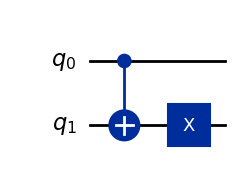

In [11]:
display(deutsch_function(3).draw(output="mpl"))

#  Deutsch algorithum for Each possible case

# Case 1:

| input $a$ | $f_1(a)$ |
|---|---|
| 0 | 0 |
| 1 | 0 |

$f_1(x)$ is constant (always 0)

Case 1: The function is constant
Measurement results for Case 1: {'0': 1024}


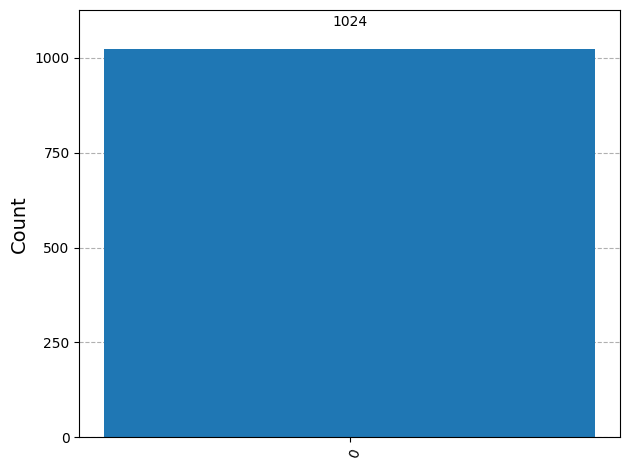

In [26]:
# Run Deutsch's algorithm for Case 1 (constant function f(x) = 0)
f1 = deutsch_function(1)
print(f"Case 1: The function is {deutsch_algorithm(f1)}")

# Get the quantum circuit for Case 1 and plot histogram
qc_f1 = compile_circuit(f1)
simulator = AerSimulator()
result = simulator.run(qc_f1, shots=1024).result()
counts = result.get_counts(qc_f1)
print("Measurement results for Case 1:", counts)
display(plot_histogram(counts))

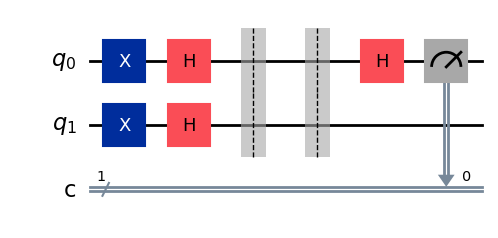

In [13]:
display(compile_circuit(deutsch_function(1)).draw(output="mpl"))

# Case 2:

| input $a$ | $f_2(a)$ |
|---|---|
| 0 | 0 |
| 1 | 1 |

$f_2(x)$ is Balance (always input)

Case 2: The function is balanced
Measurement results for Case 2: {'1': 1024}


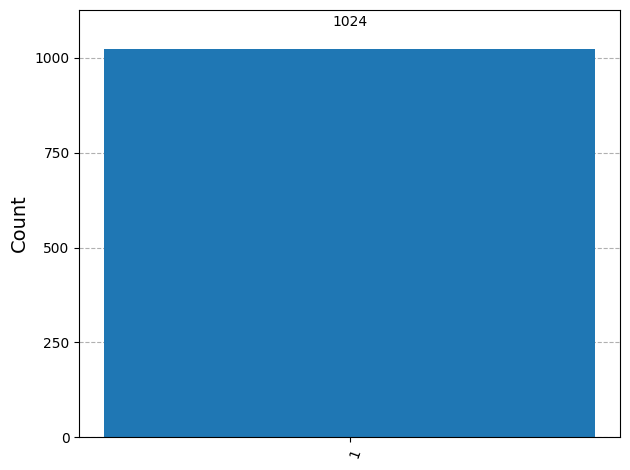

In [27]:
# Run Deutsch's algorithm for Case 2 (balanced function f(x) = x)
f2 = deutsch_function(2)
print(f"Case 2: The function is {deutsch_algorithm(f2)}")

# Get the quantum circuit for Case 2 and plot histogram
qc_f2 = compile_circuit(f2)
simulator = AerSimulator()
result = simulator.run(qc_f2, shots=1024).result()
counts = result.get_counts(qc_f2)
print("Measurement results for Case 2:", counts)
display(plot_histogram(counts))

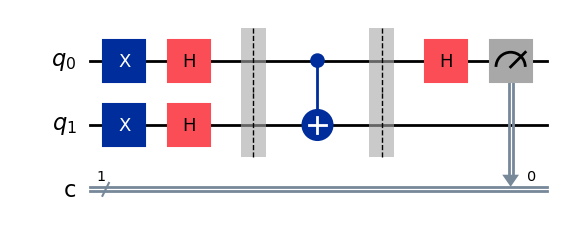

In [15]:
display(compile_circuit(deutsch_function(2)).draw(output="mpl"))

# Case 3:

| input $a$ | $f_3(a)$ |
|---|---|
| 0 | 1 |
| 1 | 0 |

$f_3(x)$ is balanced

Case 3: The function is balanced
Measurement results for Case 3: {'1': 1024}


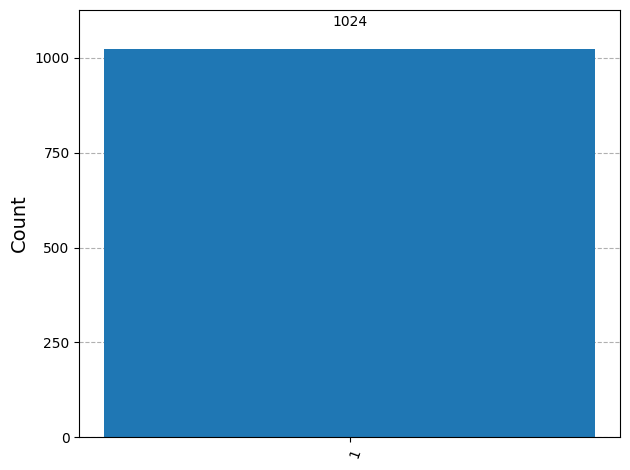

In [28]:
# Run Deutsch's algorithm for Case 3 (balanced function f(x) = NOT(x))
f3 = deutsch_function(3)
print(f"Case 3: The function is {deutsch_algorithm(f3)}")

# Get the quantum circuit for Case 3 and plot histogram
qc_f3 = compile_circuit(f3)
simulator = AerSimulator()
result = simulator.run(qc_f3, shots=1024).result()
counts = result.get_counts(qc_f3)
print("Measurement results for Case 3:", counts)
display(plot_histogram(counts))

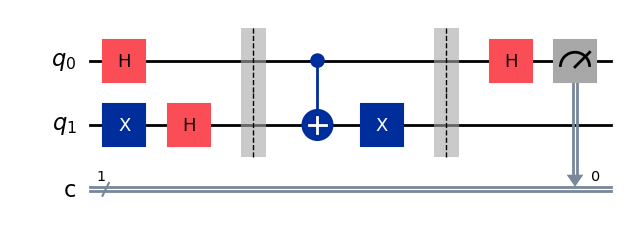

In [17]:
display(compile_circuit(deutsch_function(3)).draw(output="mpl"))

# Case 4:

| input $a$ | $f_4(a)$ |
|---|---|
| 0 | 1 |
| 1 | 1 |

$f_4(x)$ is constant.

Case 4: The function is constant
Measurement results for Case 4: {'0': 1024}


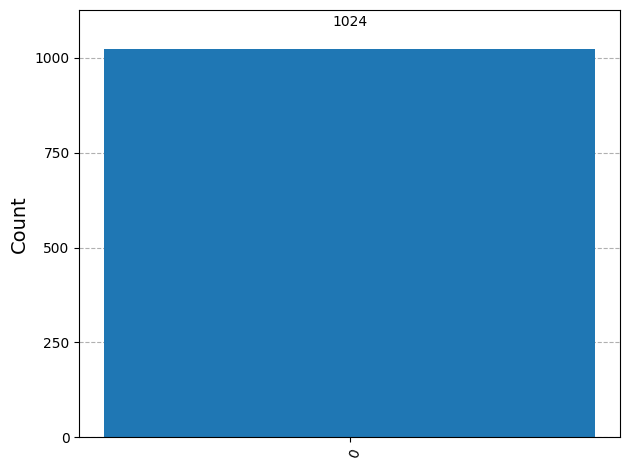

In [29]:
# Run Deutsch's algorithm for Case 4 (constant function f(x) = 1)
f4 = deutsch_function(4)
print(f"Case 4: The function is {deutsch_algorithm(f4)}")

# Get the quantum circuit for Case 4 and plot histogram
qc_f4 = compile_circuit(f4)
simulator = AerSimulator()
result = simulator.run(qc_f4, shots=1024).result()
counts = result.get_counts(qc_f4)
print("Measurement results for Case 4:", counts)
display(plot_histogram(counts))

### Histogram for Case 1 (Constant function: f(x) = 0)